In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score,
    validation_curve
)

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", None)

plt.rcParams["figure.figsize"] = (10, 6)

sns.set_theme(style="whitegrid")


reviews = pd.read_csv(
    "/Users/gabrielaslomiany/GIT/Sephora/data/processed/cleaned_reviews.csv",
    engine="python"
)

product = pd.read_csv(
    "/Users/gabrielaslomiany/GIT/Sephora/data/processed/cleaned_product_info.csv",
    engine="python"
)

In [2]:
reviews.head()

,author_id,rating,helpfulness,total_pos_feedback_count,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_name,price_usd
0,1741593524,5,1.0,2,2023-02-01,"I use this with the Nudestix “Citrus Clean Balm & Make-Up Melt“ to double cleanse and it has completely changed my skin (for the better). The make-up melt is oil based and removes all of your makeup super easily. I follow-up with this water based cleanser, and I also use this just by itself when I’m not wearing make-up. It leaves the skin gently cleansed, but without stripping the skin. 10/10 recommend combining with the make-up melt. It’s perfection!",Taught me how to double cleanse!,Doesn't apply,brown,dry,black,P504322,Gentle Hydra-Gel Face Cleanser,NUDESTIX,19.0
1,31423088263,1,NaN,0,2023-03-21,"I bought this lip mask after reading the reviews and the hype. Unfortunately, it did not meet my expectations as vaseline petroleum jelly works way better for me.",Disappointed,Doesn't apply,Doesn't apply,Doesn't apply,Doesn't apply,P420652,Lip Sleeping Mask Intense Hydration with Vitamin C,LANEIGE,24.0
2,5061282401,5,NaN,0,2023-03-21,My review title says it all! I get so excited to get into bed and apply this lip mask. I do see a difference because I suffer from dry cracked lips. I drink a lot of water and apply lip balm daily but nothing helped until I started using this. untiluntistafted usinf this.,New Favorite Routine,light,brown,dry,blonde,P420652,Lip Sleeping Mask Intense Hydration with Vitamin C,LANEIGE,24.0
3,6083038851,5,NaN,0,2023-03-20,I’ve always loved this formula for a long time. I honestly don’t even use it for night time. I use it as an everyday lip balm. I love the texture. Gummy Bear is my second most favourite scent. Grapefruit is the best in my opinion.,Can't go wrong with any of them,Doesn't apply,brown,combination,black,P420652,Lip Sleeping Mask Intense Hydration with Vitamin C,LANEIGE,24.0
4,47056667835,5,NaN,0,2023-03-20,"If you have dry cracked lips, this is a must have. After a few weeks of use I have learned I will always have by my bedside. I thought it was a little expensive but a little goes a long way. It is worth the price.",A must have !!!,light,hazel,combination,Doesn't apply,P420652,Lip Sleeping Mask Intense Hydration with Vitamin C,LANEIGE,24.0


In [3]:
reviews.describe()

,price_usd
count,600839.000000
mean,45.731057
std,35.757755
min,3.000000
25%,23.500000
50%,38.000000
75%,60.000000
max,380.000000


In [4]:
reviews.isna().sum()

author_id                        0
rating                         173
helpfulness                 331245
total_pos_feedback_count       173
submission_time                173
review_text                    173
review_title                   465
skin_tone                      465
eye_color                      465
skin_type                      465
hair_color                     757
product_id                     757
product_name                   757
brand_name                     757
price_usd                      757
dtype: int64

In [5]:
reviews.drop(columns=[    
    "author_id",    
    "helpfulness",
    "total_pos_feedback_count",
    "submission_time",
    "review_text", 
    "review_title",
    "product_name"
    "product_id",], errors="ignore", inplace=True)
reviews.dropna(subset=['skin_tone', 'eye_color', 'skin_type', 'hair_color', 'price_usd'], inplace=True)
reviews.isna().sum()

rating          0
skin_tone       0
eye_color       0
skin_type       0
hair_color      0
product_id      0
product_name    0
brand_name      0
price_usd       0
dtype: int64

In [6]:
reviews.drop(columns=[    
    "product_name"
], errors="ignore", inplace=True)
reviews.isna().sum()

rating        0
skin_tone     0
eye_color     0
skin_type     0
hair_color    0
product_id    0
brand_name    0
price_usd     0
dtype: int64

In [7]:
reviews.dtypes

rating         object
skin_tone      object
eye_color      object
skin_type      object
hair_color     object
product_id     object
brand_name     object
price_usd     float64
dtype: object

In [8]:
product.head(50)

,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,ingredients,price_usd,limited_edition,new,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count
0,P473671,Fragrance Discovery Set,6342,19-69,6320,3.64,11.0,No information,"['Capri Eau de Parfum:', 'Alcohol Denat. (SD Alcohol 39C), Parfum (Fragrance) D-Limonene, Linalool, Benzyl Salicylate, Ethylhexyl Methoxycinnamate, Butyl Methoxydibenzoylmethane, Ethylhexyl Salicylate, Benzl Benzoate, Citral, Geraniol, Eugenol, Benzyl Alcohol, Farnesol, Citronellol, Isoeugenol.', 'Invisible Post Eau de Parfum:', 'Alcohol Denat. (SD Alcohol 39C), Parfum (Fragrance) Ethylhexyl Methoxycinnamate, Ethylhexyl Salicylate, Butyl Methoxydibenzoylmethane, Benzyl Benzoate, Citral, Coumarin, Limonene, Alpha-Isomethyl Ionone, Linalool.', 'Kashbah Eau de Parfum:', 'Alcohol Denat. (SD Alcohol 39C), Parfum (Fragrance) Coumarin, Ethylhexyl Methoxycinnamate, Butyl Methoxydibenzoylmethane, Ethylhexyl Salicylate, D-Limonene, Eugenol, Linalool, Citronellol, Geraniol, Cinnamal, Citral.', 'L’Air Barbes Eau de Parfum:', 'Alcohol Denat. (SD Alcohol 39C), Parfum (Fragrance) Benzyl Salicylate, D-Limonene, Ethylhexyl Methoxycinnamate, Butyl Methoxydibenzoylmethane, Ethylhexyl Salicylate, Linalool Citral, Alphaisomethyl Ionone, Benzyl Benzoate, Geraniol Farnesol, Isoeugenol, Eugenol.', 'La Habana Eau de Parfum:', 'Alcohol Denat. (SD Alcohol 39C), Parfum (Fragrance) Ethylhexyl Methoxycinnamate, Ethylhexyl Salicylate, Butyl Methoxydibenzoylmethane, Benzyl Alcohol, Benzyl Benzoate, Benzyl Cinnamate, Cinnamal, Citral, Coumarin Limonene, Eugenol, Alpha-Isomethyl Ionone, Linalool.', 'Purple Haze Eau de Parfum:', 'Alcohol Denat. (SD Alcohol 39C), Parfum (Fragrance) Octoxynol-10, D-Limonene, Ethylhexyl Methoxycinnamate, Butyl Methoxydibenzoylmethane, Ethylhexyl Salicylate, Geraniol, Linalool, Coumarin, Farnesol, Eugenol, Citral.', 'Rainbow Bar Eau de Parfum:', 'Alcohol Denat. (SD Alcohol 39C), Parfum (Fragrance) D-Limonene, Ethylhexyl Methoxycinnamate, Butyl Methoxydibenzoylmethane, Ethylhexyl Salicylate, Hexyl Cinnamal, Citronellol, Linalool, Coumarin, Eugenol, Citral, Isoeugenol, Geraniol.']",35.0,False,False,True,False,False,"['Unisex/ Genderless Scent', 'Warm &Spicy Scent', 'Woody & Earthy Scent', 'Fresh Scent']",Fragrance,Value & Gift Sets,Perfume Gift Sets,0
1,P473668,La Habana Eau de Parfum,6342,19-69,3827,4.15,13.0,3.4 oz/ 100 mL,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fragrance) Ethylhexyl Methoxycinnamate, Ethylhexyl Salicylate, Butyl Methoxydibenzoylmethane, Benzyl Alcohol, Benzyl Benzoate, Benzyl Cinnamate, Cinnamal, Citral, Coumarin Limonene, Eugenol, Alpha-Isomethyl Ionone, Linalool.']",195.0,False,False,True,False,False,"['Unisex/ Genderless Scent', 'Layerable Scent', 'Warm &Spicy Scent']",Fragrance,Women,Perfume,2
2,P473662,Rainbow Bar Eau de Parfum,6342,19-69,3253,4.25,16.0,3.4 oz/ 100 mL,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fragrance) D-Limonene, Ethylhexyl Methoxycinnamate, Butyl Methoxydibenzoylmethane, Ethylhexyl Salicylate, Hexyl Cinnamal Citronellol, Linalool, Coumarin, Eugenol, Citral, Isoeugenol, Geraniol.']",195.0,False,False,True,False,False,"['Unisex/ Genderless Scent', 'Layerable Scent', 'Woody & Earthy Scent']",Fragrance,Women,Perfume,2
3,P473660,Kasbah Eau de Parfum,6342,19-69,3018,4.48,21.0,3.4 oz/ 100 mL,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fragrance) Coumarin, Ethylhexyl Methoxycinnamate, Butyl Methoxydibenzoylmethane, Ethylhexyl Salicylate, D-Limonene, Eugenol, Linalool, Citronellol, Geraniol, Cinnamal, Citral.']",195.0,False,False,True,False,False,"['Unisex/ Genderless Scent', 'Layerable Scent', 'Warm &Spicy Scent']",Fragrance,Women,Perfume,2
4,P473658,Purple Haze Eau de Parfum,6342,19-69,2691,3.23,13.0,3.4 oz/ 100 mL,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fragrance) Octoxynol-10, D-Limonene, Ethylhexyl Methoxycinnamate, Butyl Methoxydibenzoylmethane, Ethylhexyl Salicylate, Geran

In [9]:
product.columns

Index(['product_id', 'product_name', 'brand_id', 'brand_name', 'loves_count',
       'rating', 'reviews', 'size', 'ingredients', 'price_usd',
       'limited_edition', 'new', 'online_only', 'out_of_stock',
       'sephora_exclusive', 'highlights', 'primary_category',
       'secondary_category', 'tertiary_category', 'child_count'],
      dtype='object')

In [10]:
product.drop(columns=[        
    'product_name' #does not want to drop this column for some reason
    'product_id',
    'brand_id',
    'brand_name',
    'size', 
    'ingredients',
    'limited_edition', 
    'new', 
    'online_only', 
    'out_of_stock',
    'sephora_exclusive', 
    'highlights',
    'tertiary_category', 
    'child_count'
    ], errors="ignore", inplace=True)
# product.dropna(subset=['skin_tone', 'eye_color', 'skin_type', 'hair_color', 'price_usd'], inplace=True)
product.isna().sum()

product_id            0
product_name          0
loves_count           0
rating                0
reviews               0
price_usd             0
primary_category      0
secondary_category    0
dtype: int64

In [11]:
product.drop(columns=[        
    'product_name', 'product_id',
    ], errors="ignore", inplace=True)
print(product.columns)
product.isna().sum()

Index(['loves_count', 'rating', 'reviews', 'price_usd', 'primary_category',
       'secondary_category'],
      dtype='object')


loves_count           0
rating                0
reviews               0
price_usd             0
primary_category      0
secondary_category    0
dtype: int64

In [12]:
product.dtypes

loves_count             int64
rating                float64
reviews               float64
price_usd             float64
primary_category       object
secondary_category     object
dtype: object

## Feature selection and feature engineering

#### Dataset Selection

Although two cleaned datasets are available (`products` and `reviews`), only the **products** dataset is used for this classification task.

The objective of this notebook is to predict **whether a product will be highly rated based on its characteristics**. Since each row in the `products` dataset represents a single product, it is the appropriate level of analysis for this problem.

The `reviews` dataset contains one row per customer review rather than one row per product. Using review-level data would change the prediction task to classifying individual reviews instead of predicting product success. Additionally, products may have hundreds or thousands of reviews, resulting in multiple rows for the same product and making the classification problem fundamentally different.

#### Feature Selection

The following features were selected as predictors:

- `loves_count`
- `reviews`
- `price_usd`
- `primary_category`
- `secondary_category`

These variables describe characteristics of a product that are available before making a prediction.

The `rating` column was **removed from the feature set** because it is used to create the target variable (`high_rated`). Including `rating` as an input feature would reveal the correct answer to the model, a problem known as **data leakage**. This would lead to unrealistically high performance and prevent the model from learning meaningful relationships between product characteristics and customer ratings.

In [13]:
product["high_rated"] = (product["rating"] >= 4.5).astype(int)

In [14]:
X = product.drop(columns=["rating", "high_rated"])
y = product["high_rated"]

In [15]:
X = pd.get_dummies(
    X,
    columns=["primary_category", "secondary_category"],
    drop_first=True,
    dtype=int
)

In [16]:
print(X.shape)
X.head()

(7305, 41)


,loves_count,reviews,price_usd,primary_category_Fragrance,primary_category_Hair,primary_category_Makeup,primary_category_Men,primary_category_Skincare,primary_category_Tools & Brushes,secondary_category_Bath & Shower,secondary_category_Beauty Accessories,secondary_category_Beauty Tools,secondary_category_Body Care,secondary_category_Body Moisturizers,secondary_category_Brushes & Applicators,secondary_category_Candles & Home Scents,secondary_category_Cheek,secondary_category_Cleansers,secondary_category_Eye,secondary_category_Eye Care,secondary_category_Face,secondary_category_Hair,secondary_category_Hair Styling & Treatments,secondary_category_Hair Tools,secondary_category_High Tech Tools,secondary_category_Lip,secondary_category_Masks,secondary_category_Men,secondary_category_Moisturizers,secondary_category_Other Needs,secondary_category_Self Tanners,secondary_category_Shampoo & Conditioner,secondary_category_Shaving,secondary_category_Shop by Concern,secondary_category_Skincare,secondary_category_Sunscreen,secondary_category_Tools,secondary_category_Treatments,secondary_category_Value & Gift Sets,secondary_category_Wellness,secondary_category_Women
0,6320,11.0,35.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1,3827,13.0,195.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2,3253,16.0,195.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
3,3018,21.0,195.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4,2691,13.0,195.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [18]:
print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

Training set: (5844, 41)
Testing set: (1461, 41)


In [19]:
scaler = StandardScaler()

numerical_features = [
    "loves_count",
    "reviews",
    "price_usd"
]

X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

## Model Training

Several machine learning models are trained to predict whether a product is highly rated.

A **Dummy Classifier** is first used as a baseline. This simple model does not learn from the data but instead predicts the most frequent class. It provides a minimum performance benchmark that more advanced models should outperform.

The main classification models used in this notebook are **K-Nearest Neighbours (KNN)** and **Logistic Regression**.

In [20]:
dummy_model = DummyClassifier(strategy="most_frequent")
dummy_model.fit(X_train, y_train)
y_dummy_pred = dummy_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_dummy_pred):.3f}")

Accuracy: 0.702


In [21]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_knn_pred = knn_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_knn_pred):.3f}")

Accuracy: 0.690


In [22]:
logistic_model = LogisticRegression(
    solver="saga",
    random_state=42,
    max_iter=5000
)

logistic_model.fit(X_train, y_train)

y_logistic_pred = logistic_model.predict(X_test)

print(accuracy_score(y_test, y_logistic_pred))

0.702258726899384


/Users/gabrielaslomiany/GIT/Sephora/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/gabrielaslomiany/GIT/Sephora/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/gabrielaslomiany/GIT/Sephora/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [23]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)
y_linear_pred = linear_model.predict(X_test)
y_linear_class = (y_linear_pred >= 0.5).astype(int)
print(f"Accuracy: {accuracy_score(y_test, y_linear_class):.3f}")

Accuracy: 0.702


/Users/gabrielaslomiany/GIT/Sephora/.venv/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/gabrielaslomiany/GIT/Sephora/.venv/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/gabrielaslomiany/GIT/Sephora/.venv/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


## Hyperparameter Tuning

The performance of the K-Nearest Neighbours (KNN) classifier depends on the choice of the number of neighbours (`k`).

A small value of `k` may lead to overfitting, while a large value may oversimplify the decision boundary and reduce model performance.

To determine the optimal value, the classifier is trained using several values of `k`. The accuracy on the testing set is recorded for each model, and the value producing the highest accuracy is selected for the final KNN classifier.

In [24]:
k_values = range(1, 31, 2)

accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    accuracies.append(accuracy_score(y_test, y_pred))

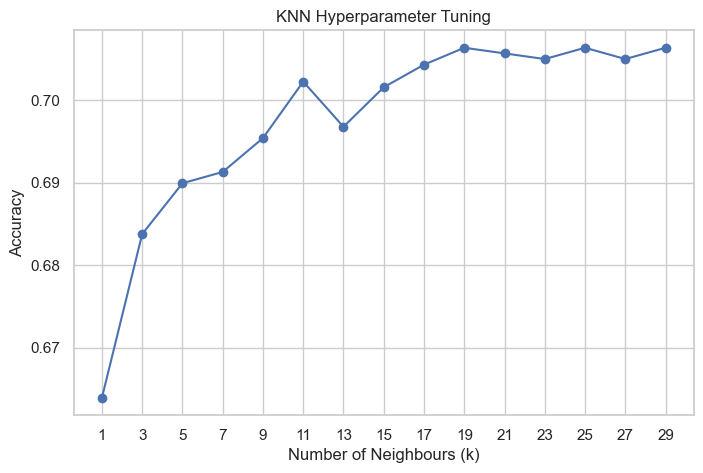

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    accuracies,
    marker="o"
)

plt.xlabel("Number of Neighbours (k)")
plt.ylabel("Accuracy")
plt.title("KNN Hyperparameter Tuning")

plt.xticks(k_values)

plt.grid(True)

plt.show()

In [26]:
best_k = k_values[np.argmax(accuracies)]

best_accuracy = max(accuracies)

print(f"Best k: {best_k}")
print(f"Best Accuracy: {best_accuracy:.3f}")

Best k: 19
Best Accuracy: 0.706


In [27]:
knn_model = KNeighborsClassifier(
    n_neighbors=best_k
)
knn_model.fit(X_train, y_train)
y_knn_pred = knn_model.predict(X_test)

print(f"Final KNN Accuracy: {accuracy_score(y_test, y_knn_pred):.3f}")

Final KNN Accuracy: 0.706


#### Compared to previous KNN this has improved in terms of accuracy

In [28]:
knn_precision = precision_score(y_test, y_knn_pred)
knn_recall = recall_score(y_test, y_knn_pred)
knn_f1 = f1_score(y_test, y_knn_pred)

print(f"Precision: {knn_precision:.3f}")
print(f"Recall:    {knn_recall:.3f}")
print(f"F1-score:  {knn_f1:.3f}")

Precision: 0.517
Recall:    0.205
F1-score:  0.293


In [29]:
print(classification_report(y_test, y_knn_pred))

              precision    recall  f1-score   support

           0       0.73      0.92      0.81      1026
           1       0.52      0.20      0.29       435

    accuracy                           0.71      1461
   macro avg       0.62      0.56      0.55      1461
weighted avg       0.67      0.71      0.66      1461



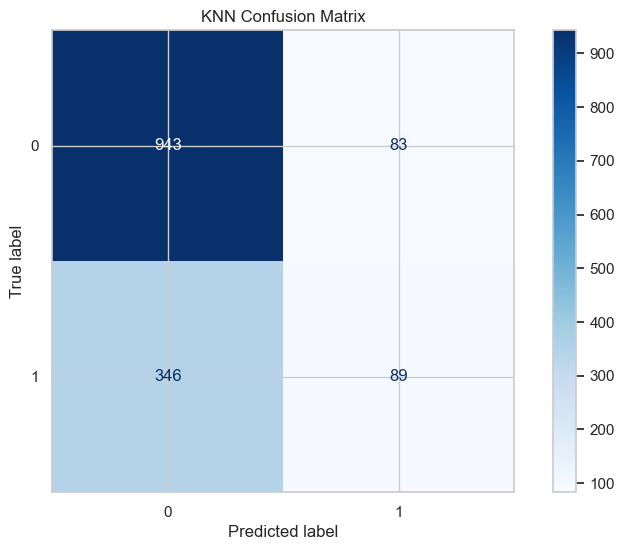

In [30]:
cm = confusion_matrix(y_test, y_knn_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot(cmap="Blues")

plt.title("KNN Confusion Matrix")

plt.show()

### Observations

The confusion matrix shows that the KNN classifier performs well at identifying products that are **not highly rated** (class 0), correctly classifying **943** out of **1,026** such products. Only **83** products from this class were incorrectly predicted as highly rated.

However, the model performs considerably worse when identifying **highly rated products** (class 1). It correctly classified only **89** products, while **346** highly rated products were incorrectly predicted as not highly rated.

These results indicate that the model is biased towards predicting the majority class. Although the overall accuracy is reasonable, the low number of true positives suggests that the classifier struggles to recognize highly rated products. This is also reflected in the relatively low recall for class 1.

## Conclusions

The K-Nearest Neighbours (KNN) classifier achieved an accuracy of approximately **70%**, demonstrating that product characteristics such as the number of loves, reviews, price, and product categories contain useful information for predicting whether a product is highly rated.

The confusion matrix showed that the model performed well when identifying products that were **not highly rated**, but struggled to correctly classify highly rated products. This suggests that the model is influenced by the class imbalance in the dataset and tends to predict the majority class more frequently.

At this stage, KNN has been fully trained, tuned, and evaluated. It serves as the first benchmark model for this classification task.

Attempts were also made to train **Logistic Regression** and **Linear Regression** models. However, both models produced unexpected runtime warnings originating from the underlying scikit-learn and NumPy libraries during matrix multiplication. Since the dataset was verified to contain no missing values, infinite values, or incorrect data types, the issue appears to be related to the software environment rather than the preprocessing pipeline.

As a result, the evaluation of Logistic Regression and Linear Regression has been postponed until the numerical issue is resolved. Once fixed, their performance will be compared against the KNN classifier to determine the most suitable model for predicting highly rated Sephora products.